<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/adsorption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fixed-bed CO₂ adsorption and regeneration with NeqSim

**Audience.** Process, gas-treatment, and simulation engineers who know basic Python and
steady-state thermodynamics.

**Prerequisites.** Familiarity with gas composition, packed beds, and mole fractions is useful.
No local files or proprietary data are required.

**Learning objectives**

- build a reproducible SRK natural-gas feed and a composable NeqSim `Stream`;
- obtain 13X Langmuir parameters and equilibrium loadings from NeqSim;
- configure `AdsorptionBed` geometry, kinetics, pressure drop, and axial cells;
- simulate a CO₂ breakthrough curve with the transient LDF model;
- screen pressure, temperature, flow, and regeneration effects;
- verify bounds, packed-bed hydraulics, trends, and cyclic working capacity.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        "neqsim",
    ]
    subprocess.check_call(install_command)

## 1. Engineering question and validity boundary

The example screens removal of 10 mol% CO₂ from a dry natural-gas surrogate at 50 bara and
35°C using a fixed bed of zeolite 13X. It predicts equilibrium loading, pressure drop,
breakthrough, and high-temperature/low-pressure regeneration.

The NeqSim parameter database is appropriate for teaching and comparative screening. Final
design requires vendor isotherms for the specified adsorbent batch, multicomponent breakthrough
data, heat-of-adsorption effects, cycle sequencing, ageing, contaminants, and mechanical design.
The calculation is not a guarantee of product CO₂ specification or bed life.

In [2]:
import importlib.metadata
import json
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jpype import JClass

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


AdsorptionBed = jneqsim.process.equipment.adsorber.AdsorptionBed
IsothermType = (
    jneqsim.physicalproperties.interfaceproperties.solidadsorption.IsothermType
)
LangmuirAdsorption = (
    jneqsim.physicalproperties.interfaceproperties.solidadsorption.LangmuirAdsorption
)
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream
UUID = JClass("java.util.UUID")
JavaSystem = JClass("java.lang.System")

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            importlib.metadata.version("neqsim"),
            platform.python_version(),
            str(JavaSystem.getProperty("java.version")),
        ],
    }
)
runtime_table

  Runtime  Version
0  NeqSim   3.16.0
1  Python  3.12.13
2    Java  17.0.19

## 2. Fluid representation and model choice

The feed contains methane, CO₂, and nitrogen on a molar basis. SRK is selected because this is a
single gas phase at moderate temperature and pressure. The adsorption calculation uses NeqSim
fugacities and its built-in 13X parameters. Pressure is absolute; flow is mass flow.

The composition sum is checked explicitly. A `Stream` preserves the feed as a named object that
can be connected to a larger NeqSim process.

In [3]:
FEED_TEMPERATURE_C = 35.0
FEED_PRESSURE_BARA = 50.0
BASE_MASS_FLOW_KG_H = 5000.0
COMPONENTS = ["methane", "CO2", "nitrogen"]
MOLE_FRACTIONS = [0.89, 0.10, 0.01]
CO2_INDEX = COMPONENTS.index("CO2")


def create_feed_stream(mass_flow_kg_h=BASE_MASS_FLOW_KG_H):
    feed_fluid = fluid("srk")
    for component_name, mole_fraction in zip(COMPONENTS, MOLE_FRACTIONS):
        feed_fluid.addComponent(component_name, mole_fraction)

    feed_fluid.setMixingRule("classic")
    feed_fluid.setMultiPhaseCheck(True)
    feed_fluid.setTemperature(FEED_TEMPERATURE_C, "C")
    feed_fluid.setPressure(FEED_PRESSURE_BARA, "bara")
    TPflash(feed_fluid)
    feed_fluid.initProperties()

    feed_stream = Stream("CO2-rich feed gas", feed_fluid)
    feed_stream.setFlowRate(mass_flow_kg_h, "kg/hr")
    feed_stream.run()
    return feed_stream


feed = create_feed_stream()

### Feed-state check

The feed must remain one gas phase before entering the bed. A condensed phase would invalidate
the dry-gas adsorption assumptions and could damage a real molecular-sieve bed.

In [4]:
feed_fluid = feed.getFluid()
composition_rows = []
for component_index, component_name in enumerate(COMPONENTS):
    mole_fraction = feed_fluid.getComponent(component_index).getz()
    composition_rows.append(
        {
            "Component": component_name,
            "Feed mole fraction (-)": mole_fraction,
        }
    )

composition_table = pd.DataFrame(composition_rows)
feed_state_table = pd.DataFrame(
    {
        "Quantity": [
            "Temperature",
            "Pressure",
            "Mass flow",
            "Gas density",
            "Gas viscosity",
            "Number of phases",
        ],
        "Value": [
            feed.getTemperature("C"),
            feed.getPressure("bara"),
            feed.getFlowRate("kg/hr"),
            feed_fluid.getDensity("kg/m3"),
            feed_fluid.getViscosity("kg/msec"),
            feed_fluid.getNumberOfPhases(),
        ],
        "Unit": ["°C", "bara", "kg/h", "kg/m³", "Pa s", "-"],
    }
)

print(composition_table.to_string(index=False))
feed_state_table

Component  Feed mole fraction (-)
  methane                    0.89
      CO2                    0.10
 nitrogen                    0.01


           Quantity        Value   Unit
0       Temperature    35.000000     °C
1          Pressure    50.000000   bara
2         Mass flow  5000.000000   kg/h
3       Gas density    40.125775  kg/m³
4     Gas viscosity     0.000013   Pa s
5  Number of phases     1.000000      -

## 3. Langmuir equilibrium

For one adsorbate, the Langmuir loading is

$$
q_i = q_{max,i}\frac{K_i f_i}{1 + K_i f_i}
$$

where $q_i$ is loading in mol/kg, $q_{max,i}$ is saturation capacity in mol/kg, $K_i$ is the
affinity coefficient in 1/bar, and $f_i$ is component fugacity in bar. The model assumes a
finite set of uniform sites and is used here as a component-wise screening model. Competitive
multicomponent adsorption requires calibrated Extended-Langmuir or other isotherm parameters.

In [5]:
def configure_adsorption_bed(inlet_stream, number_of_cells=20):
    adsorption_bed = AdsorptionBed("13X CO2 adsorption bed", inlet_stream)
    adsorption_bed.setBedDiameter(1.0)
    adsorption_bed.setBedLength(4.0)
    adsorption_bed.setVoidFraction(0.38)
    adsorption_bed.setAdsorbentMaterial("Zeolite 13X")
    adsorption_bed.setAdsorbentBulkDensity(620.0)
    adsorption_bed.setParticleDiameter(0.002)
    adsorption_bed.setParticlePorosity(0.40)
    adsorption_bed.setIsothermType(IsothermType.LANGMUIR)
    adsorption_bed.setKLDF(0.02)
    adsorption_bed.setNumberOfCells(number_of_cells)
    adsorption_bed.setCalculatePressureDrop(True)
    return adsorption_bed


bed = configure_adsorption_bed(feed)
bed.setCalculateSteadyState(True)

process = ProcessSystem()
process.add(feed)
process.add(bed)
process.run()

bed_report = json.loads(str(bed.toJson()))
geometry_table = pd.DataFrame(
    {
        "Quantity": [
            "Internal diameter",
            "Packed length",
            "Bed volume",
            "Adsorbent mass",
            "Void fraction",
            "Particle diameter",
        ],
        "Value": [
            bed.getBedDiameter(),
            bed.getBedLength(),
            bed.getBedVolume(),
            bed.getAdsorbentMass(),
            bed.getVoidFraction(),
            bed.getParticleDiameter(),
        ],
        "Unit": ["m", "m", "m³", "kg", "-", "m"],
    }
)
geometry_table

            Quantity        Value Unit
0  Internal diameter     1.000000    m
1      Packed length     4.000000    m
2         Bed volume     3.141593   m³
3     Adsorbent mass  1207.628216   kg
4      Void fraction     0.380000    -
5  Particle diameter     0.002000    m

### NeqSim isotherm parameters

`AdsorptionBed` initializes a Langmuir model from NeqSim's adsorption parameter database. The
equilibrium loading is a thermodynamic ceiling, not the instantaneous bed loading. The transient
model approaches it through finite-rate mass transfer.

In [6]:
isotherm_model = bed.getIsothermModel()
isotherm_rows = []
for component_index, component_name in enumerate(COMPONENTS):
    isotherm_rows.append(
        {
            "Component": component_name,
            "qmax (mol/kg)": isotherm_model.getQmax(component_index),
            "K at reference (1/bar)": isotherm_model.getKLangmuir(
                component_index
            ),
            "Equilibrium loading (mol/kg)": isotherm_model.getSurfaceExcess(
                component_index
            ),
        }
    )

isotherm_table = pd.DataFrame(isotherm_rows)
co2_equilibrium_loading = float(
    isotherm_table.loc[
        isotherm_table["Component"] == "CO2",
        "Equilibrium loading (mol/kg)",
    ].iloc[0]
)
isotherm_table

  Component  ...  Equilibrium loading (mol/kg)
0   methane  ...                      4.400139
1       CO2  ...                      6.823077
2  nitrogen  ...                      0.085634

[3 rows x 4 columns]

### Selectivity interpretation

The equilibrium loading ratio alone is not selectivity because feed concentrations differ. A
useful screening quantity compares solid loading per unit gas mole fraction:

$$
\alpha_{i/j} = \frac{q_i / y_i}{q_j / y_j}
$$

Large $α_{CO_2/CH_4}$ indicates preferential CO₂ uptake under the stated model. It does not
replace a competitive breakthrough experiment.

In [7]:
co2_loading = isotherm_model.getSurfaceExcess(CO2_INDEX)
methane_loading = isotherm_model.getSurfaceExcess(0)
co2_selectivity = (
    co2_loading / MOLE_FRACTIONS[CO2_INDEX]
) / (
    methane_loading / MOLE_FRACTIONS[0]
)

selectivity_table = pd.DataFrame(
    {
        "Metric": [
            "CO2 equilibrium loading",
            "Methane equilibrium loading",
            "CO2/CH4 screening selectivity",
        ],
        "Value": [co2_loading, methane_loading, co2_selectivity],
        "Unit": ["mol/kg", "mol/kg", "-"],
    }
)
selectivity_table

                          Metric      Value    Unit
0        CO2 equilibrium loading   6.823077  mol/kg
1    Methane equilibrium loading   4.400139  mol/kg
2  CO2/CH4 screening selectivity  13.800788       -

## 4. Packed-bed hydraulics

NeqSim applies the Ergun equation, combining viscous and inertial pressure losses:

$$
\frac{\Delta P}{L} =
\frac{150\mu u_s(1-\varepsilon)^2}{\varepsilon^3 d_p^2}
+ \frac{1.75\rho u_s^2(1-\varepsilon)}{\varepsilon^3 d_p}
$$

Here $μ$ is gas viscosity in Pa s, $ρ$ is gas density in kg/m³, $u_s$ is superficial
velocity in m/s, $ε$ is void fraction, and $d_p$ is particle diameter in m.

In [8]:
gas_density = feed_fluid.getDensity("kg/m3")
gas_viscosity = feed_fluid.getViscosity("kg/msec")
mass_flow_kg_s = feed.getFlowRate("kg/sec")
actual_flow_m3_s = mass_flow_kg_s / gas_density
bed_area_m2 = math.pi * bed.getBedDiameter() ** 2 / 4.0
superficial_velocity_m_s = actual_flow_m3_s / bed_area_m2
void_fraction = bed.getVoidFraction()
particle_diameter_m = bed.getParticleDiameter()

viscous_gradient_pa_m = (
    150.0
    * gas_viscosity
    * superficial_velocity_m_s
    * (1.0 - void_fraction) ** 2
    / (void_fraction**3 * particle_diameter_m**2)
)
inertial_gradient_pa_m = (
    1.75
    * gas_density
    * superficial_velocity_m_s**2
    * (1.0 - void_fraction)
    / (void_fraction**3 * particle_diameter_m)
)
ergun_pressure_drop_pa = bed.getBedLength() * (
    viscous_gradient_pa_m + inertial_gradient_pa_m
)
neqsim_pressure_drop_pa = bed.getPressureDrop()
pressure_drop_relative_residual = (
    neqsim_pressure_drop_pa - ergun_pressure_drop_pa
) / ergun_pressure_drop_pa

hydraulic_table = pd.DataFrame(
    {
        "Quantity": [
            "Superficial velocity",
            "NeqSim pressure drop",
            "Independent Ergun pressure drop",
            "Relative residual",
        ],
        "Value": [
            superficial_velocity_m_s,
            neqsim_pressure_drop_pa,
            ergun_pressure_drop_pa,
            pressure_drop_relative_residual,
        ],
        "Unit": ["m/s", "Pa", "Pa", "-"],
    }
)
hydraulic_table

                          Quantity         Value Unit
0             Superficial velocity  4.407113e-02  m/s
1             NeqSim pressure drop  3.703548e+03   Pa
2  Independent Ergun pressure drop  3.703548e+03   Pa
3                Relative residual -6.139348e-16    -

## 5. Transient mass transfer and breakthrough

The bed is divided into axial cells. Each cell uses a linear-driving-force (LDF) rate:

$$
\frac{dq_i}{dt} = k_{LDF,i}(q_i^* - q_i)
$$

$k_{LDF}$ is in 1/s, $q_i^*$ is equilibrium loading, and $q_i$ is current loading. The value
0.02 1/s is an explicit educational assumption within the documented zeolite range.

Component breakthrough is defined here from the CO₂ concentration ratio, rather than the bed's
generic any-component flag:

$$
B_{CO_2}(t) = \frac{C_{CO_2,out}(t)}{C_{CO_2,in}}
$$

The 5%, 50%, and 95% thresholds characterize the protected period and front passage.

In [9]:
def simulate_breakthrough(adsorption_bed, inlet_stream, duration_s, time_step_s):
    adsorption_bed.setCalculateSteadyState(False)
    adsorption_bed.setBreakthroughThreshold(0.05)
    adsorption_bed.resetBed()

    gas_phase = inlet_stream.getFluid().getPhase("gas")
    inlet_molar_density = 1.0 / gas_phase.getMolarVolume("m3/mol")
    inlet_co2_fraction = inlet_stream.getFluid().getComponent(CO2_INDEX).getz()
    inlet_co2_concentration = inlet_molar_density * inlet_co2_fraction

    identifier = UUID.randomUUID()
    records = []
    snapshots = {}
    snapshot_times = {200.0, 500.0, 700.0}
    number_of_steps = int(round(duration_s / time_step_s))

    for step_index in range(number_of_steps):
        adsorption_bed.runTransient(time_step_s, identifier)
        elapsed_time_s = (step_index + 1) * time_step_s
        concentration_profile = np.asarray(
            list(adsorption_bed.getConcentrationProfile(CO2_INDEX)),
            dtype=float,
        )
        raw_leakage = concentration_profile[-1] / inlet_co2_concentration
        records.append(
            {
                "Time (s)": elapsed_time_s,
                "Raw CO2 leakage (-)": raw_leakage,
                "Average CO2 loading (mol/kg)": adsorption_bed.getAverageLoading(
                    CO2_INDEX
                ),
            }
        )

        if elapsed_time_s in snapshot_times:
            snapshots[elapsed_time_s] = concentration_profile / inlet_co2_concentration

    results = pd.DataFrame(records)
    results["CO2 breakthrough envelope (-)"] = np.maximum.accumulate(
        results["Raw CO2 leakage (-)"].to_numpy()
    )
    return results, snapshots, inlet_co2_concentration


def first_threshold_time(results, threshold):
    crossed = results[
        results["CO2 breakthrough envelope (-)"] >= threshold
    ]
    if crossed.empty:
        return math.nan
    return float(crossed.iloc[0]["Time (s)"])

### Base breakthrough run

The external time step is 2 s. NeqSim automatically applies CFL-limited internal substeps. Twenty
cells provide a compact demonstration; quantitative mass-transfer-zone work should use a grid
study and calibrated kinetics.

In [10]:
bed.setNumberOfCells(20)
breakthrough_results, concentration_snapshots, inlet_co2_concentration = (
    simulate_breakthrough(
        bed,
        feed,
        duration_s=800.0,
        time_step_s=2.0,
    )
)

breakthrough_5_s = first_threshold_time(breakthrough_results, 0.05)
breakthrough_50_s = first_threshold_time(breakthrough_results, 0.50)
breakthrough_95_s = first_threshold_time(breakthrough_results, 0.95)
final_loading_mol_kg = float(
    breakthrough_results["Average CO2 loading (mol/kg)"].iloc[-1]
)

breakthrough_summary = pd.DataFrame(
    {
        "Metric": [
            "5% CO2 breakthrough",
            "50% CO2 breakthrough",
            "95% CO2 breakthrough",
            "Final average CO2 loading",
            "Final CO2 leakage",
        ],
        "Value": [
            breakthrough_5_s,
            breakthrough_50_s,
            breakthrough_95_s,
            final_loading_mol_kg,
            breakthrough_results["Raw CO2 leakage (-)"].iloc[-1],
        ],
        "Unit": ["s", "s", "s", "mol/kg", "-"],
    }
)
breakthrough_summary

                      Metric       Value    Unit
0        5% CO2 breakthrough   66.000000       s
1       50% CO2 breakthrough  506.000000       s
2       95% CO2 breakthrough  644.000000       s
3  Final average CO2 loading    6.822046  mol/kg
4          Final CO2 leakage    0.996743       -

### Breakthrough interpretation

The early flat region is the protected operating window. The steep rise is the mass-transfer
zone reaching the outlet. A cumulative envelope is used only to locate threshold crossings;
the raw curve remains plotted so numerical diffusion or small oscillations stay visible.

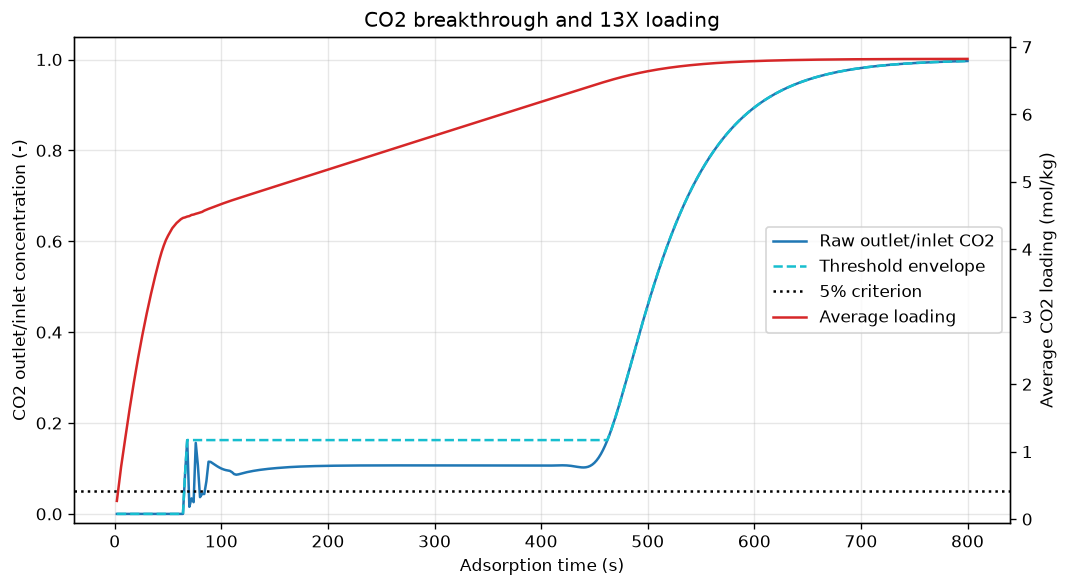

In [11]:
figure, left_axis = plt.subplots(figsize=(9, 5))
left_axis.plot(
    breakthrough_results["Time (s)"],
    breakthrough_results["Raw CO2 leakage (-)"],
    label="Raw outlet/inlet CO2",
    color="tab:blue",
)
left_axis.plot(
    breakthrough_results["Time (s)"],
    breakthrough_results["CO2 breakthrough envelope (-)"],
    label="Threshold envelope",
    color="tab:cyan",
    linestyle="--",
)
left_axis.axhline(0.05, color="black", linestyle=":", label="5% criterion")
left_axis.set_xlabel("Adsorption time (s)")
left_axis.set_ylabel("CO2 outlet/inlet concentration (-)")
left_axis.set_ylim(-0.02, 1.05)
left_axis.grid(alpha=0.3)

right_axis = left_axis.twinx()
right_axis.plot(
    breakthrough_results["Time (s)"],
    breakthrough_results["Average CO2 loading (mol/kg)"],
    label="Average loading",
    color="tab:red",
)
right_axis.set_ylabel("Average CO2 loading (mol/kg)")

left_lines, left_labels = left_axis.get_legend_handles_labels()
right_lines, right_labels = right_axis.get_legend_handles_labels()
left_axis.legend(left_lines + right_lines, left_labels + right_labels, loc="center right")
left_axis.set_title("CO2 breakthrough and 13X loading")
figure.tight_layout()

### Axial concentration front

The profiles show the front moving from the inlet at $z=0$ toward the outlet at $z=L$. A broad
front reflects both finite LDF kinetics and first-order numerical diffusion.

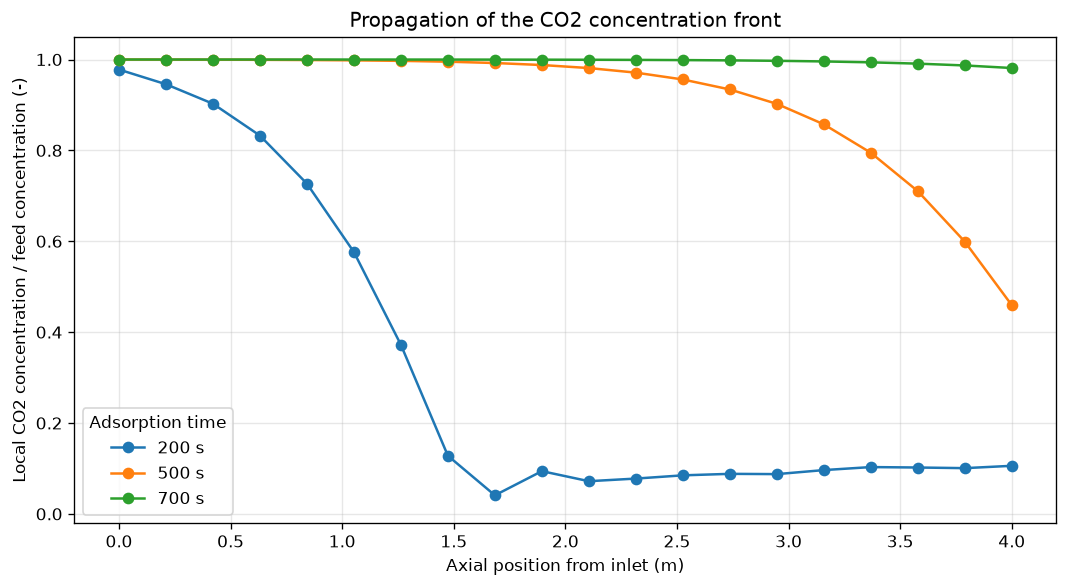

In [12]:
axial_positions_m = np.linspace(0.0, bed.getBedLength(), bed.getNumberOfCells())

figure, axis = plt.subplots(figsize=(9, 5))
for snapshot_time_s, normalized_profile in concentration_snapshots.items():
    axis.plot(
        axial_positions_m,
        normalized_profile,
        marker="o",
        label=f"{snapshot_time_s:.0f} s",
    )

axis.set_xlabel("Axial position from inlet (m)")
axis.set_ylabel("Local CO2 concentration / feed concentration (-)")
axis.set_ylim(-0.02, 1.05)
axis.set_yticks(np.linspace(0.0, 1.0, 6))
axis.set_title("Propagation of the CO2 concentration front")
axis.grid(alpha=0.3)
axis.legend(title="Adsorption time")
figure.tight_layout()

## 6. Equilibrium pressure and temperature sensitivity

Adsorption is exothermic, so affinity normally decreases as temperature rises. Pressure increases
fugacity and therefore loading until the Langmuir plateau is approached. NeqSim evaluates both
effects through the fluid fugacity and temperature-dependent parameter model.

In [13]:
def calculate_co2_equilibrium_loading(temperature_c, pressure_bara):
    state_stream = create_feed_stream(mass_flow_kg_h=BASE_MASS_FLOW_KG_H)
    state_fluid = state_stream.getFluid()
    state_fluid.setTemperature(temperature_c, "C")
    state_fluid.setPressure(pressure_bara, "bara")
    TPflash(state_fluid)
    state_fluid.initProperties()

    model = LangmuirAdsorption(state_fluid)
    model.setSolidMaterial("Zeolite 13X")
    model.calcAdsorption(0)
    return model.getSurfaceExcess(CO2_INDEX)


temperature_cases_c = [25.0, 35.0, 50.0]
pressure_cases_bara = [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
equilibrium_rows = []
for temperature_c in temperature_cases_c:
    for pressure_bara in pressure_cases_bara:
        equilibrium_rows.append(
            {
                "Temperature (°C)": temperature_c,
                "Pressure (bara)": pressure_bara,
                "CO2 loading (mol/kg)": calculate_co2_equilibrium_loading(
                    temperature_c,
                    pressure_bara,
                ),
            }
        )

equilibrium_sensitivity = pd.DataFrame(equilibrium_rows)
equilibrium_sensitivity.head(9)

   Temperature (°C)  Pressure (bara)  CO2 loading (mol/kg)
0              25.0             10.0              6.141176
1              25.0             20.0              6.628571
2              25.0             30.0              6.808696
3              25.0             40.0              6.902479
4              25.0             50.0              6.960000
5              25.0             60.0              6.998883
6              35.0             10.0              5.641695
7              35.0             20.0              6.326300
8              35.0             30.0              6.592980

### Equilibrium trend plot

Pressure and temperature effects are shown separately so the result can be used as a qualitative
screen when choosing adsorption and regeneration conditions.

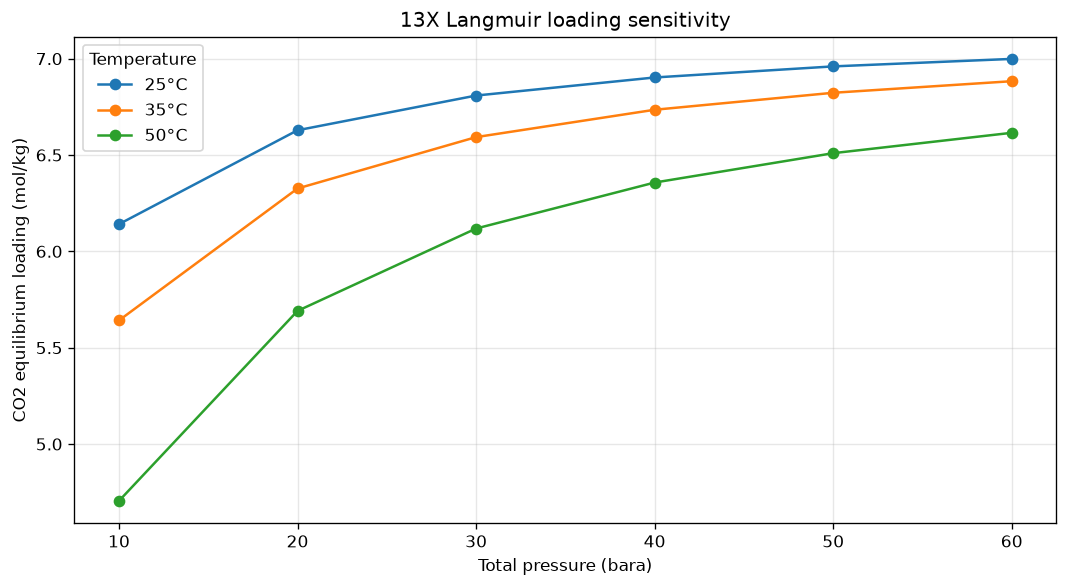

In [14]:
figure, axis = plt.subplots(figsize=(9, 5))
for temperature_c in temperature_cases_c:
    case_rows = equilibrium_sensitivity[
        equilibrium_sensitivity["Temperature (°C)"] == temperature_c
    ]
    axis.plot(
        case_rows["Pressure (bara)"],
        case_rows["CO2 loading (mol/kg)"],
        marker="o",
        label=f"{temperature_c:.0f}°C",
    )

axis.set_xlabel("Total pressure (bara)")
axis.set_ylabel("CO2 equilibrium loading (mol/kg)")
axis.set_title("13X Langmuir loading sensitivity")
axis.grid(alpha=0.3)
axis.legend(title="Temperature")
figure.tight_layout()

## 7. Flow-rate sensitivity and hydraulic limitation

Changing flow does not change the equilibrium isotherm at fixed composition, temperature, and
pressure. It does increase superficial velocity, pressure drop, and front speed. The packed-bed
pressure drop should rise faster than linearly once the inertial Ergun term matters.

In [15]:
flow_cases_kg_h = [2500.0, 5000.0, 7500.0, 10000.0]
flow_rows = []
for mass_flow_kg_h in flow_cases_kg_h:
    case_feed = create_feed_stream(mass_flow_kg_h=mass_flow_kg_h)
    case_bed = configure_adsorption_bed(case_feed, number_of_cells=20)
    case_bed.setCalculateSteadyState(True)

    case_process = ProcessSystem()
    case_process.add(case_feed)
    case_process.add(case_bed)
    case_process.run()

    case_density = case_feed.getFluid().getDensity("kg/m3")
    case_actual_flow_m3_s = case_feed.getFlowRate("kg/sec") / case_density
    case_velocity_m_s = case_actual_flow_m3_s / bed_area_m2
    flow_rows.append(
        {
            "Mass flow (kg/h)": mass_flow_kg_h,
            "Superficial velocity (m/s)": case_velocity_m_s,
            "Pressure drop (Pa)": case_bed.getPressureDrop(),
        }
    )

flow_sensitivity = pd.DataFrame(flow_rows)
flow_sensitivity

   Mass flow (kg/h)  Superficial velocity (m/s)  Pressure drop (Pa)
0            2500.0                    0.022036         1081.259534
1            5000.0                    0.044071         3703.547898
2            7500.0                    0.066107         7866.865092
3           10000.0                    0.088142        13571.211115

## 8. PSA/TSA-style regeneration

After the adsorption front has crossed the bed, the demonstration applies 1 bara and 150°C as
regeneration equilibrium conditions with clean purge gas. The cyclic working capacity is

$$
\Delta q_{work} = q_{loaded} - q_{regenerated}
$$

The model is isothermal within each step; it does not solve the solid energy balance or heater
duty. Those effects are essential in detailed TSA design.

In [16]:
loading_before_regeneration = bed.getAverageLoading(CO2_INDEX)
bed.setDesorptionMode(True)
bed.setDesorptionPressure(1.0)
bed.setDesorptionTemperature(423.15)

regeneration_identifier = UUID.randomUUID()
regeneration_records = []
regeneration_time_step_s = 2.0
for step_index in range(150):
    bed.runTransient(regeneration_time_step_s, regeneration_identifier)
    regeneration_records.append(
        {
            "Regeneration time (s)": (step_index + 1) * regeneration_time_step_s,
            "Average CO2 loading (mol/kg)": bed.getAverageLoading(CO2_INDEX),
        }
    )

regeneration_results = pd.DataFrame(regeneration_records)
loading_after_regeneration = float(
    regeneration_results["Average CO2 loading (mol/kg)"].iloc[-1]
)
working_capacity_mol_kg = loading_before_regeneration - loading_after_regeneration
regenerated_fraction = working_capacity_mol_kg / loading_before_regeneration

regeneration_summary = pd.DataFrame(
    {
        "Metric": [
            "Loading before regeneration",
            "Loading after regeneration",
            "Cyclic working capacity",
            "Regenerated fraction",
        ],
        "Value": [
            loading_before_regeneration,
            loading_after_regeneration,
            working_capacity_mol_kg,
            regenerated_fraction,
        ],
        "Unit": ["mol/kg", "mol/kg", "mol/kg", "-"],
    }
)
regeneration_summary

                        Metric     Value    Unit
0  Loading before regeneration  6.822046  mol/kg
1   Loading after regeneration  0.338952  mol/kg
2      Cyclic working capacity  6.483094  mol/kg
3         Regenerated fraction  0.950315       -

### Regeneration response

The loading should decrease monotonically toward a low-pressure/high-temperature equilibrium.
The remaining loading represents the working-capacity penalty at the selected regeneration time.

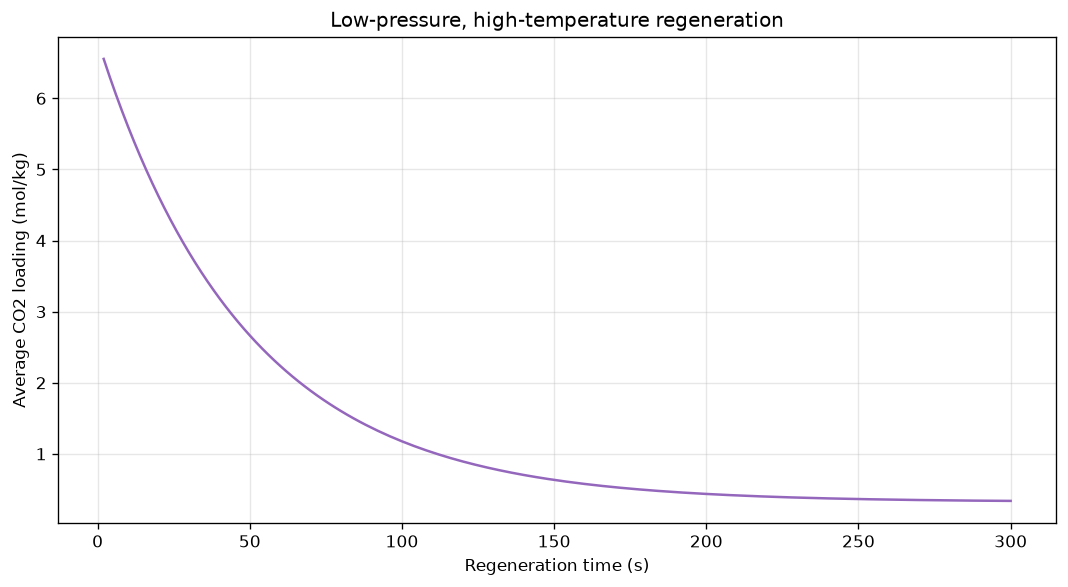

In [17]:
figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(
    regeneration_results["Regeneration time (s)"],
    regeneration_results["Average CO2 loading (mol/kg)"],
    color="tab:purple",
)
axis.set_xlabel("Regeneration time (s)")
axis.set_ylabel("Average CO2 loading (mol/kg)")
axis.set_title("Low-pressure, high-temperature regeneration")
axis.grid(alpha=0.3)
figure.tight_layout()

## 9. Engineering validation

The checks cover software execution, feed definition, phase state, Langmuir bounds, selectivity,
geometry, Ergun pressure drop, breakthrough ordering, numerical smoothness, isotherm trends,
hydraulic trends, and regeneration. They are screening checks rather than design certification.

In [18]:
checks = []


def record_check(condition, description):
    assert bool(condition), description
    checks.append(description)


record_check(abs(sum(MOLE_FRACTIONS) - 1.0) < 1.0e-12, "feed composition closes")
record_check(feed_fluid.getNumberOfPhases() == 1, "feed remains one gas phase")
record_check(gas_density > 0.0, "gas density is positive")
record_check(gas_viscosity > 0.0, "gas viscosity is positive")
record_check(abs(feed.getPressure("bara") - 50.0) < 1.0e-8, "feed pressure is correct")
record_check(co2_loading > methane_loading, "CO2 loading exceeds methane loading")
record_check(co2_selectivity > 1.0, "CO2/CH4 screening selectivity exceeds unity")

for row in isotherm_rows:
    record_check(
        0.0 <= row["Equilibrium loading (mol/kg)"] <= row["qmax (mol/kg)"],
        f"{row['Component']} loading is within Langmuir bounds",
    )

expected_bed_volume_m3 = math.pi * bed.getBedDiameter() ** 2 * bed.getBedLength() / 4.0
expected_adsorbent_mass_kg = (
    expected_bed_volume_m3
    * (1.0 - bed.getVoidFraction())
    * bed.getAdsorbentBulkDensity()
)
record_check(
    abs(bed.getBedVolume() - expected_bed_volume_m3) < 1.0e-10,
    "bed volume matches geometry",
)
record_check(
    abs(bed.getAdsorbentMass() - expected_adsorbent_mass_kg) < 1.0e-8,
    "adsorbent inventory matches geometry",
)
record_check(neqsim_pressure_drop_pa > 0.0, "packed-bed pressure drop is positive")
record_check(
    abs(pressure_drop_relative_residual) < 1.0e-10,
    "NeqSim pressure drop matches the independent Ergun equation",
)
record_check(math.isfinite(breakthrough_5_s), "5 percent breakthrough is reached")
record_check(
    breakthrough_5_s < breakthrough_50_s < breakthrough_95_s,
    "breakthrough thresholds are correctly ordered",
)
record_check(
    breakthrough_results["Raw CO2 leakage (-)"].iloc[0] < 0.01,
    "fresh bed initially protects the outlet",
)
record_check(
    breakthrough_results["Raw CO2 leakage (-)"].iloc[-1] > 0.95,
    "saturated bed approaches feed concentration",
)
raw_leakage_values = breakthrough_results["Raw CO2 leakage (-)"].to_numpy()
record_check(
    np.all((raw_leakage_values >= 0.0) & (raw_leakage_values <= 1.05)),
    "raw breakthrough curve remains within physical concentration bounds",
)
record_check(
    final_loading_mol_kg <= co2_equilibrium_loading * 1.01,
    "final loading respects the equilibrium ceiling",
)

for temperature_c in temperature_cases_c:
    temperature_rows = equilibrium_sensitivity[
        equilibrium_sensitivity["Temperature (°C)"] == temperature_c
    ]
    loading_changes = np.diff(temperature_rows["CO2 loading (mol/kg)"].to_numpy())
    record_check(
        np.all(loading_changes > 0.0),
        f"loading increases with pressure at {temperature_c:.0f} degrees C",
    )

for pressure_bara in pressure_cases_bara:
    pressure_rows = equilibrium_sensitivity[
        equilibrium_sensitivity["Pressure (bara)"] == pressure_bara
    ]
    temperature_changes = np.diff(pressure_rows["CO2 loading (mol/kg)"].to_numpy())
    record_check(
        np.all(temperature_changes < 0.0),
        f"loading decreases with temperature at {pressure_bara:.0f} bara",
    )

record_check(
    np.all(np.diff(flow_sensitivity["Pressure drop (Pa)"].to_numpy()) > 0.0),
    "pressure drop increases with flow",
)
record_check(working_capacity_mol_kg > 0.0, "regeneration creates working capacity")
record_check(regenerated_fraction > 0.90, "regeneration removes over 90 percent of loading")
record_check(
    np.all(
        np.diff(regeneration_results["Average CO2 loading (mol/kg)"].to_numpy())
        <= 1.0e-10
    ),
    "regeneration loading decreases monotonically",
)

print(f"All {len(checks)} engineering checks passed.")

All 33 engineering checks passed.


## 10. Results, troubleshooting, and next steps

**Interpretation.** The model links SRK gas fugacity, 13X equilibrium data, axial LDF transport,
and Ergun hydraulics in one composable NeqSim unit. Breakthrough time changes with feed loading,
kinetics, bed inventory, and velocity; it must not be transferred to another adsorbent without
recalibration.

**Troubleshooting**

- Condensed feed: lower water/heavy-hydrocarbon content or add upstream separation and heating.
- Excessive pressure drop: increase diameter, increase pellet size, or reduce flow after checking
  mass-transfer consequences.
- Immediate breakthrough: verify component index, fresh-bed reset, units, and inlet concentration.
- Slow execution: reduce cells for screening, then restore at least 50 cells for MTZ refinement.
- Poor regeneration: reduce pressure, increase temperature/time, or model a stronger purge.

**Further exercises**

1. Replace generic parameters with licensed vendor isotherm and kinetic data.
2. Compare Langmuir, Extended Langmuir, Sips, and DRA equilibrium predictions.
3. Add water and H₂S competition and verify that the feed remains gas phase.
4. Configure a complete multi-bed PSA or TSA cycle with heat and purge balances.
5. Couple pressure-drop and bed-size constraints to NeqSim mechanical design.

**References**

- [NeqSim adsorption-bed documentation](https://equinor.github.io/neqsim/process/equipment/adsorption_bed.html)
- [NeqSim adsorption-isotherm models](https://equinor.github.io/neqsim/thermo/adsorption_isotherms.html)
- [NeqSim process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)

In [19]:
final_summary = pd.DataFrame(
    {
        "Result": [
            "CO2 equilibrium loading",
            "CO2/CH4 screening selectivity",
            "Packed-bed pressure drop",
            "5% CO2 breakthrough time",
            "95% CO2 breakthrough time",
            "Cyclic working capacity",
            "Regenerated fraction",
            "Engineering checks",
        ],
        "Value": [
            co2_equilibrium_loading,
            co2_selectivity,
            neqsim_pressure_drop_pa,
            breakthrough_5_s,
            breakthrough_95_s,
            working_capacity_mol_kg,
            regenerated_fraction,
            len(checks),
        ],
        "Unit": [
            "mol/kg",
            "-",
            "Pa",
            "s",
            "s",
            "mol/kg",
            "-",
            "passed",
        ],
    }
)

print("Fixed-bed adsorption screening completed with NeqSim.")
final_summary

Fixed-bed adsorption screening completed with NeqSim.


                          Result        Value    Unit
0        CO2 equilibrium loading     6.823077  mol/kg
1  CO2/CH4 screening selectivity    13.800788       -
2       Packed-bed pressure drop  3703.547898      Pa
3       5% CO2 breakthrough time    66.000000       s
4      95% CO2 breakthrough time   644.000000       s
5        Cyclic working capacity     6.483094  mol/kg
6           Regenerated fraction     0.950315       -
7             Engineering checks    33.000000  passed